In [1]:
import pandas, numpy, sklearn, matplotlib, seaborn
print ("All 5 tools are ready!")  

All 5 tools are ready!


In [1]:
import pandas as pd 
df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print(df.shape)
print(df.dtypes)
df.info()
df.head()

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
(df == 0).sum()  

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

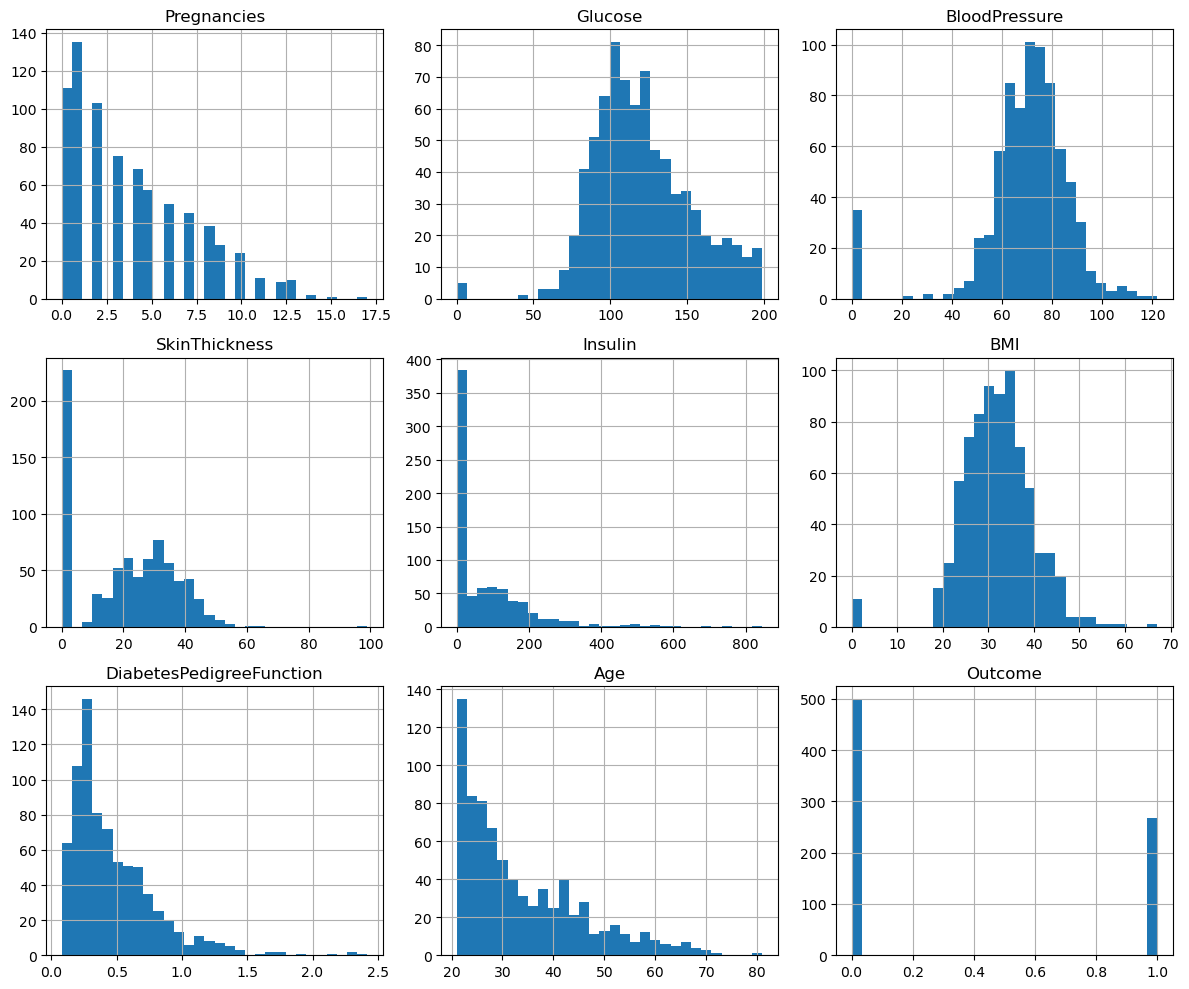

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
## Histogram Observations
- Roughly normal: Glucose, BloodPressure, BMI
- Right-skewed: Pregnancies, Age, DiabetesPedigreeFunction
- severe Zero-spike (missing data in disguise):Insulin(374), skinThickness (227) 
- Minor Zero-spike: Glucose (5), BloodPressure (35), BMI (11)
- Outcome is imbalanced: ~500 no-diabetes vs ~268 diabetes

In [6]:
import os
print(os.getcwd())

C:\Users\Tuba Masood


In [7]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


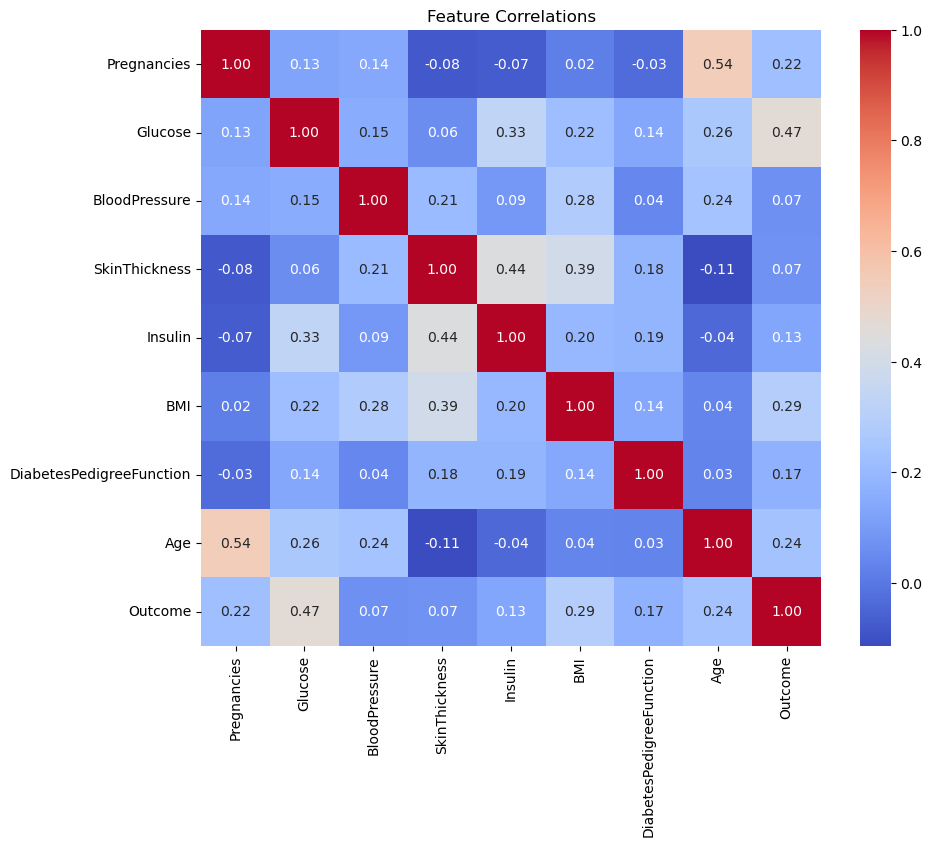

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlations")
plt.show()

## Correlation observations
1. Glucose is the strongest predictor of diabetes (0.47) - by far the most important single feature.
2. BMI (0.29), Age (0.24), and pregnancies (0.22) show moderate positive correlation - useful secondary predictors.
3. BloodPressure (0.07) and SkinThickness (0.07) barely correlate with outcome - likely weak predictors. (Bonus: Pregnancies & Age correlate at 0.54 with each other.)

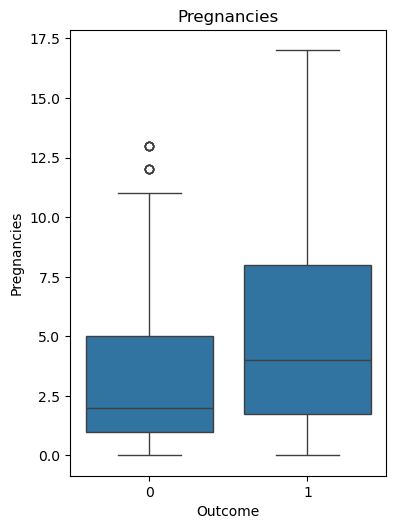

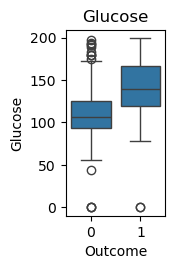

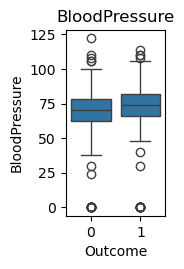

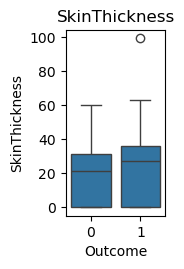

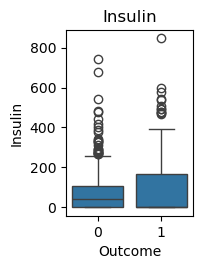

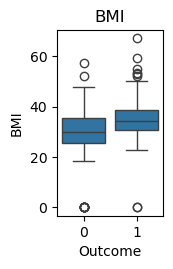

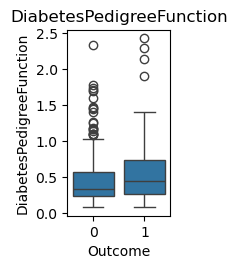

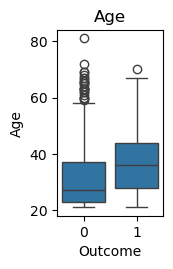

In [14]:
import matplotlib.pyplot as plt

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plt.figure(figsize=(14,10))
for i, col in enumerate(features):
    plt.subplot(2,4,i+1)
    sns.boxplot(x='Outcome',y=col, data=df)
    plt.title(col)
    plt.tight_layout()
    plt.show()

## Boxplot observations
- Strongest separation: Glucose - diabetic median ~140 sits clearly above non-diabetic ~107
- Moderate separation: BMI, Age, Pregnancies.
- Poor separation (boxes overlap): BloodPressure, SkinThickness.
- Visually confirms the heatmap: Glucose is the #1 predictor of diabetes.

## Statistics notes (StatQuest)
- Distribution = the shape of the data. My Glucose is roughly normal; Pregnancies are right-skewed.
- Correlation (-1 to +1) = how much two features move together. Glucose and Outcome = 0.47, the strongest.
- Correlation is not causation: Glucose predicts diabetes, but that alone does not prove it causes it.

# Exploratory Data Analysis Summary — PIMA Diabetes Dataset

## 1. What is the data?
This dataset contains 768 records of women (all Pima heritage, aged 21+), with 8 health features and 1 target column (Outcome: 0 = no diabetes, 1 = diabetes). The features are Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age. The classes are imbalanced: about 500 non-diabetic vs 268 diabetic.

## 2. What is wrong with it?
Several columns contain zeros that are biologically impossible and are really missing values in disguise. The worst affected are Insulin (374 zeros) and SkinThickness (227), followed by BloodPressure (35), BMI (11), and Glucose (5). Note that zeros in Pregnancies are valid and should NOT be treated as missing. Several features are also right-skewed (Pregnancies, Age, DiabetesPedigreeFunction, Insulin).

## 3. What looks predictive?
Glucose is by far the strongest predictor of diabetes (correlation 0.47), confirmed visually by clear separation in its boxplot. BMI (0.29), Age (0.24), and Pregnancies (0.22) are moderate predictors. BloodPressure and SkinThickness correlate weakly (~0.07), and their boxplots overlap heavily, suggesting they are weak predictors on their own.

## Next steps
Clean the disguised-missing zeros (e.g. replace with median) before modeling, and account for the class imbalance.

## Article Notes — EDA Process

**Source:** "Exploratory Data Analysis in 11 Steps" by Loren Hinkson, Towards Data Science
**Link:** [Read the article](https://towardsdatascience.com/exploratory-data-analysis-in-11-steps-31a36ae0b407/)

### 3 things I learned
1. Real-world EDA is mostly communication, not code. A lot of the process is talking to stakeholders, agreeing on goals, and setting expectations *before* touching the data.
2. Documenting findings should include the "so what?" — not just what I found, but why it matters and what to do next.
3. The technical work I did this weekend (cleaning missing data, checking distributions and correlations, documenting findings) maps to steps 7–10 of a full professional EDA process.